In [1]:
# BLOQUE 0: LIBRERÍAS Y CARGA DE DATOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Cargar base
df = pd.read_excel("/Users/karlavega/Proyectos/Colaborativos/Forest_Peru/Datos/resultados_distrital.xlsx")

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip().str.lower()

# Renombrar "año" a "anio" para evitar problemas en fórmulas
if "año" in df.columns:
    df = df.rename(columns={"año": "anio"})

df.head()


,ubigeo,anio,region,provincia,distrito,organizacion_politica,total_votos,orden_aparicion
0,10102,2022,Amazonas,Chachapoyas,Asunción,MOVIMIENTO REGIONAL VICTORIA AMAZONENSE,108,1
1,10102,2022,Amazonas,Chachapoyas,Asunción,ALIANZA PARA EL PROGRESO,159,2
2,10103,2022,Amazonas,Chachapoyas,Balsas,SENTIMIENTO AMAZONENSE REGIONAL,120,1
3,10103,2022,Amazonas,Chachapoyas,Balsas,MOVIMIENTO REGIONAL VICTORIA AMAZONENSE,40,2
4,10103,2022,Amazonas,Chachapoyas,Balsas,RENOVACION POPULAR,130,3


In [2]:
# BLOQUE 1: VARIABLES DE PANEL

# Identificador de elección distrito-año
df["id_eleccion"] = df["ubigeo"].astype(str) + "_" + df["anio"].astype(str)

# Determinar ganador: 1 si tiene el máximo de votos en su distrito-año
df["winner"] = df.groupby(["ubigeo", "anio"])["total_votos"] \
                 .transform(lambda x: x == x.max()).astype(int)
df.head()

,ubigeo,anio,region,provincia,distrito,organizacion_politica,total_votos,orden_aparicion,id_eleccion,winner
0,10102,2022,Amazonas,Chachapoyas,Asunción,MOVIMIENTO REGIONAL VICTORIA AMAZONENSE,108,1,10102_2022,0
1,10102,2022,Amazonas,Chachapoyas,Asunción,ALIANZA PARA EL PROGRESO,159,2,10102_2022,1
2,10103,2022,Amazonas,Chachapoyas,Balsas,SENTIMIENTO AMAZONENSE REGIONAL,120,1,10103_2022,0
3,10103,2022,Amazonas,Chachapoyas,Balsas,MOVIMIENTO REGIONAL VICTORIA AMAZONENSE,40,2,10103_2022,0
4,10103,2022,Amazonas,Chachapoyas,Balsas,RENOVACION POPULAR,130,3,10103_2022,0


Probabilidad de ganar por orden de aparición:
    orden_aparicion    winner
0                 1  0.241021
1                 2  0.214094
2                 3  0.192627
3                 4  0.156325
4                 5  0.149183
5                 6  0.111302
6                 7  0.082372
7                 8  0.078144
8                 9  0.080074
9                10  0.045699
10               11  0.088353
11               12  0.028409
12               13  0.040650
13               14  0.070588
14               15  0.052632
15               16  0.050000
16               17  0.000000
17               18  0.105263
18               19  0.100000
19               20  0.600000
20               21  0.000000
21               22  0.000000
22               23  0.000000


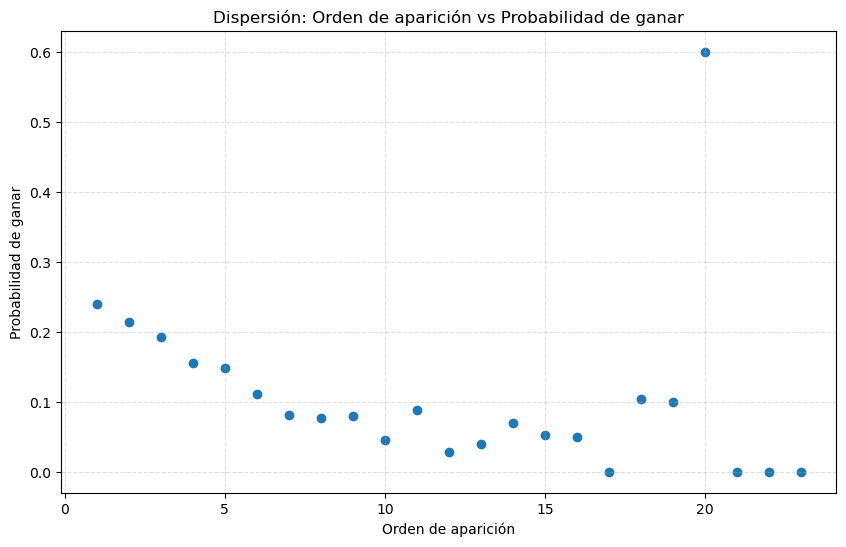

In [3]:
# BLOQUE 2: DESCRIPTIVOS Y DISPERSIÓN

# Probabilidad de ganar según orden de aparición
prob_orden = (
    df.groupby("orden_aparicion")["winner"]
      .mean()
      .reset_index()
      .sort_values("orden_aparicion")
)

print("Probabilidad de ganar por orden de aparición:")
print(prob_orden)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(prob_orden["orden_aparicion"], prob_orden["winner"])
plt.xlabel("Orden de aparición")
plt.ylabel("Probabilidad de ganar")
plt.title("Dispersión: Orden de aparición vs Probabilidad de ganar")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


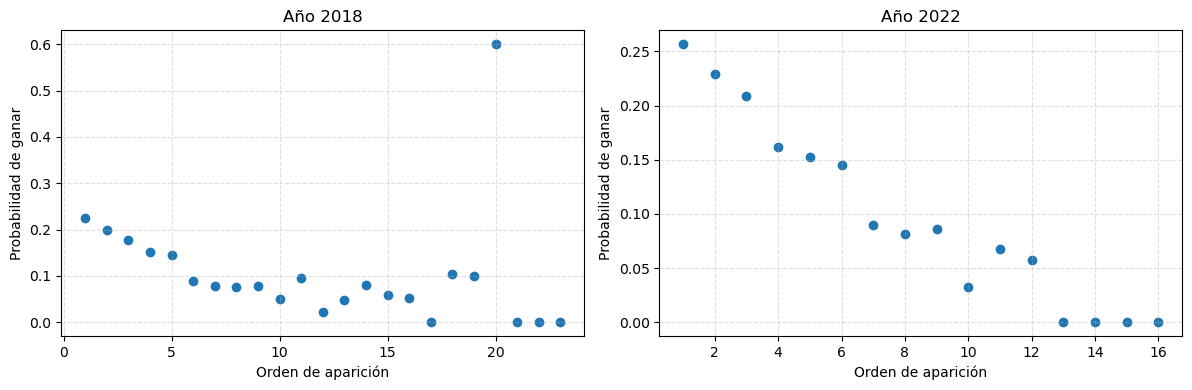

In [4]:
# DISPERSIÓN DE ORDEN VS PROBABILIDAD DE GANAR POR AÑO

import matplotlib.pyplot as plt

# Obtener lista de años en la base
anios = sorted(df["anio"].unique())

# Definir tamaño del layout dinámicamente según cuántos años haya
n = len(anios)
cols = 3
rows = (n // cols) + (1 if n % cols != 0 else 0)

plt.figure(figsize=(6 * cols, 4 * rows))

for i, anio in enumerate(anios, 1):
    df_a = df[df["anio"] == anio]

    # Probabilidad de ganar por orden para ese año
    prob_a = (
        df_a.groupby("orden_aparicion")["winner"]
            .mean()
            .reset_index()
            .sort_values("orden_aparicion")
    )

    # Subplot
    ax = plt.subplot(rows, cols, i)
    ax.scatter(prob_a["orden_aparicion"], prob_a["winner"])
    ax.set_title(f"Año {anio}")
    ax.set_xlabel("Orden de aparición")
    ax.set_ylabel("Probabilidad de ganar")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [5]:
# BLOQUE 3: MODELO BASE SIMPLE

mod_base = smf.ols("winner ~ orden_aparicion", data=df) \
              .fit(cov_type="cluster", cov_kwds={"groups": df["ubigeo"]})

print(mod_base.summary())


                            OLS Regression Results                            
Dep. Variable:                 winner   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     547.0
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          4.90e-105
Time:                        02:18:32   Log-Likelihood:                -8663.6
No. Observations:               20694   AIC:                         1.733e+04
Df Residuals:                   20692   BIC:                         1.735e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2441      0.004     

In [6]:
# BLOQUE 4: MODELO PRINCIPAL (FE PROVINCIA + FE AÑO)

formula_principal = """
winner ~ orden_aparicion
          + C(provincia) + C(anio)
"""

mod_principal = smf.ols(formula_principal, data=df) \
                   .fit(cov_type="cluster", cov_kwds={"groups": df["ubigeo"]})

print(mod_principal.summary())


                            OLS Regression Results                            
Dep. Variable:                 winner   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     764.6
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:18:35   Log-Likelihood:                -8564.9
No. Observations:               20694   AIC:                         1.752e+04
Df Residuals:                   20497   BIC:                         1.909e+04
Df Model:                         196                                         
Covariance Type:              cluster                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [7]:
# BLOQUE 5.1: EFECTOS FIJOS POR PROVINCIA

mod_fe_prov = smf.ols(
    "winner ~ orden_aparicion + C(provincia)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["ubigeo"]})

print(mod_fe_prov.summary())


                            OLS Regression Results                            
Dep. Variable:                 winner   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     913.7
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:18:37   Log-Likelihood:                -8577.2
No. Observations:               20694   AIC:                         1.755e+04
Df Residuals:                   20498   BIC:                         1.910e+04
Df Model:                         195                                         
Covariance Type:              cluster                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [8]:
# BLOQUE 5.3: MODELO LOGIT 

formula_logit = """
winner ~ orden_aparicion + C(provincia) + C(anio)
"""

mod_logit = smf.logit(formula_logit, data=df).fit()
print(mod_logit.summary())


Optimization terminated successfully.
         Current function value: 0.432176
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                20694
Model:                          Logit   Df Residuals:                    20497
Method:                           MLE   Df Model:                          196
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                 0.03697
Time:                        02:18:40   Log-Likelihood:                -8943.5
converged:                       True   LL-Null:                       -9286.8
Covariance Type:            nonrobust   LLR p-value:                 1.025e-55
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -

In [9]:
# ============================================================
# 2. Crear variable 'gana' (ganador por año y distrito/ubigeo)
#    Criterio: el que tiene mayor total_votos dentro de
#    (anio, ubigeo) o (anio, region, provincia, distrito)
# ============================================================

# Usaré ubigeo como identificador de distrito
grupo = ["anio", "ubigeo"]

# Ordenar por votos descendente
df = df.sort_values(by=grupo + ["total_votos"], ascending=[True, True, False])

# El ganador es el primer partido dentro de cada grupo
df["gana"] = df.groupby(grupo).cumcount().eq(0).astype(int)

# Comprobación rápida
print(df[["anio", "ubigeo", "organizacion_politica", "total_votos", "gana"]].head(20))


      anio  ubigeo                           organizacion_politica  \
9091  2018   10102         MOVIMIENTO INDEPENDIENTE SURGE AMAZONAS   
9092  2018   10102                 SENTIMIENTO AMAZONENSE REGIONAL   
9097  2018   10103                 SENTIMIENTO AMAZONENSE REGIONAL   
9096  2018   10103           MOVIMIENTO REGIONAL FUERZA AMAZONENSE   
9093  2018   10103                        ALIANZA PARA EL PROGRESO   
9094  2018   10103         MOVIMIENTO INDEPENDIENTE SURGE AMAZONAS   
9095  2018   10103  MOVIMIENTO REGIONAL AMAZONENSE UNIDOS AL CAMPO   
9099  2018   10104           MOVIMIENTO REGIONAL FUERZA AMAZONENSE   
9100  2018   10104                 SENTIMIENTO AMAZONENSE REGIONAL   
9098  2018   10104  MOVIMIENTO REGIONAL AMAZONENSE UNIDOS AL CAMPO   
9101  2018   10105         MOVIMIENTO INDEPENDIENTE SURGE AMAZONAS   
9103  2018   10105                 SENTIMIENTO AMAZONENSE REGIONAL   
9102  2018   10105           MOVIMIENTO REGIONAL FUERZA AMAZONENSE   
9107  2018   10106  

In [10]:
# ============================================================
# 3. Ganadores 2018 y 2022 por ubigeo
# ============================================================

ganadores_2018 = df[(df["anio"] == 2018) & (df["gana"] == 1)].copy()
ganadores_2022 = df[(df["anio"] == 2022) & (df["gana"] == 1)].copy()

# Nos quedamos solo con lo esencial para el merge
ganadores_2018 = ganadores_2018[[
    "ubigeo", "region", "provincia", "distrito", "organizacion_politica"
]].rename(columns={"organizacion_politica": "partido_2018"})

ganadores_2022 = ganadores_2022[[
    "ubigeo", "region", "provincia", "distrito", "organizacion_politica", "orden_aparicion"
]].rename(columns={
    "organizacion_politica": "partido_2022",
    "orden_aparicion": "orden_2022"
})

In [11]:
# ============================================================
# 4. Construir TURNOVER a nivel de ubigeo
#    turnover = 0 si el ganador 2018 = ganador 2022
#    turnover = 1 si cambia el partido ganador
# ============================================================

turnover_df = pd.merge(
    ganadores_2018,
    ganadores_2022,
    on=["ubigeo", "region", "provincia", "distrito"],
    how="inner"  # exige que exista ganador en ambos años
)

turnover_df["turnover"] = (turnover_df["partido_2018"] != turnover_df["partido_2022"]).astype(int)

# Opcional: revisar
print(turnover_df.head())

   ubigeo    region    provincia     distrito  \
0   10102  Amazonas  Chachapoyas     Asunción   
1   10103  Amazonas  Chachapoyas       Balsas   
2   10104  Amazonas  Chachapoyas        Cheto   
3   10105  Amazonas  Chachapoyas    Chiliquin   
4   10106  Amazonas  Chachapoyas  Chuquibamba   

                              partido_2018  \
0  MOVIMIENTO INDEPENDIENTE SURGE AMAZONAS   
1          SENTIMIENTO AMAZONENSE REGIONAL   
2    MOVIMIENTO REGIONAL FUERZA AMAZONENSE   
3  MOVIMIENTO INDEPENDIENTE SURGE AMAZONAS   
4          SENTIMIENTO AMAZONENSE REGIONAL   

                              partido_2022  orden_2022  turnover  
0                 ALIANZA PARA EL PROGRESO           2         1  
1                 ALIANZA PARA EL PROGRESO           4         1  
2  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE           2         1  
3          SENTIMIENTO AMAZONENSE REGIONAL           1         1  
4          SENTIMIENTO AMAZONENSE REGIONAL           1         0  


In [12]:
# ============================================================
# 5. Variable INCUMBENTE para cada partido en 2022
#    incumbente = 1 si la organizacion_politica en 2022
#    es la misma que la que gobernaba en 2018 en ese ubigeo
# ============================================================

# Creamos un diccionario: ubigeo -> partido_2018 ganador
map_partido_2018 = ganadores_2018.set_index("ubigeo")["partido_2018"].to_dict()

# Tomamos solo año 2022
df_2022 = df[df["anio"] == 2022].copy()

# Partido que gobernaba en 2018 en ese ubigeo
df_2022["partido_gob_2018"] = df_2022["ubigeo"].map(map_partido_2018)

# incumbente = 1 si el partido actual = partido_2018, sino 0
df_2022["incumbente"] = (df_2022["organizacion_politica"] == df_2022["partido_gob_2018"]).astype(int)


In [13]:
# ============================================================
# 6. Interacción
# ============================================================

df_2022["orden_incumbente"] = df_2022["orden_aparicion"] * df_2022["incumbente"]


df_2022["gana_incumbente"] = df_2022["gana"] * df_2022["incumbente"]


In [14]:
# ============================================================
# 7. Añadir variable Y (gana o pierde en 2022)
#    Ya la tenemos como 'gana' desde el paso 2
# ============================================================

# Asegurarse de que es numérica
df_2022["gana"] = df_2022["gana"].astype(float)

In [15]:
# ============================================================
# 8. Preparar datos para regresión:
#    Y = gana
#    X = orden_aparicion, incumbente, orden_incumbente
#    FE = provincia (modelo 1) y región (modelo 2)
# ============================================================


# Aseguramos tipos básicos
df_2022["gana"] = df_2022["gana"].astype(float)
df_2022["orden_aparicion"] = df_2022["orden_aparicion"].astype(float)
df_2022["incumbente"] = df_2022["incumbente"].astype(int)
df_2022["orden_incumbente"] = df_2022["orden_incumbente"].astype(float)
df_2022["gana_incumbente"] = df_2022["gana_incumbente"].astype(float)

In [16]:
# ============================================================
# 8.1 Modelo con EF por PROVINCIA
#     gana = orden_aparicion + incumbente + orden_incumbente + FE(provincia)
# ============================================================

formula_prov = """
gana ~ orden_aparicion + incumbente + orden_incumbente + gana_incumbente + C(provincia)
"""

# Creamos identificador de provincia para cluster (si quieres clustering)
df_2022["provincia_id"] = df_2022["provincia"].astype("category").cat.codes

modelo_prov = smf.ols(formula=formula_prov, data=df_2022)
res_prov = modelo_prov.fit(cov_type="cluster", cov_kwds={"groups": df_2022["provincia_id"]})

print("\n======================")
print("Modelo con FE por PROVINCIA")
print("======================")
print(res_prov.summary())


Modelo con FE por PROVINCIA
                            OLS Regression Results                            
Dep. Variable:                   gana   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                 1.116e+04
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          4.87e-228
Time:                        02:20:04   Log-Likelihood:                -3881.7
No. Observations:                9091   AIC:                             8161.
Df Residuals:                    8892   BIC:                             9577.
Df Model:                         198                                         
Covariance Type:              cluster                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 198, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [17]:
# ============================================================
# 8.2 Modelo con EF por REGION
#     gana = orden_aparicion + incumbente + orden_incumbente + FE(region)
# ============================================================

formula_reg = """
gana ~ orden_aparicion + incumbente + orden_incumbente + gana_incumbente + C(region)
"""

# Identificador de región para cluster (si quieres)
df_2022["region_id"] = df_2022["region"].astype("category").cat.codes

modelo_reg = smf.ols(formula=formula_reg, data=df_2022)
res_reg = modelo_reg.fit(cov_type="cluster", cov_kwds={"groups": df_2022["region_id"]})

print("\n======================")
print("Modelo con FE por REGION")
print("======================")
print(res_reg.summary())


Modelo con FE por REGION
                            OLS Regression Results                            
Dep. Variable:                   gana   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                 1.525e+05
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           1.79e-52
Time:                        02:20:22   Log-Likelihood:                -3918.0
No. Observations:                9091   AIC:                             7894.
Df Residuals:                    9062   BIC:                             8100.
Df Model:                          28                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [19]:
# ============================================================
# 1. Definir modelos
# ============================================================

formula_reg = "gana_incumbente ~ orden_aparicion + C(region)"
formula_prov = "gana_incumbente ~ orden_aparicion + C(provincia)"

# Identificadores para clustering
df_2022["region_id"] = df_2022["region"].astype("category").cat.codes
df_2022["provincia_id"] = df_2022["provincia"].astype("category").cat.codes

# Modelo FE Región
modelo_reg = smf.ols(formula=formula_reg, data=df_2022)
res_reg = modelo_reg.fit(cov_type="cluster", cov_kwds={"groups": df_2022["region_id"]})

# Modelo FE Provincia
modelo_prov = smf.ols(formula=formula_prov, data=df_2022)
res_prov = modelo_prov.fit(cov_type="cluster", cov_kwds={"groups": df_2022["provincia_id"]})


# ============================================================
# 2. Función para obtener significancia tipo *, **, ***
# ============================================================

def stars(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''


# ============================================================
# 3. Extraer coeficientes y SE para ambas regresiones
# ============================================================

variables = ["orden_aparicion"]

tabla = pd.DataFrame(index=[
    "Orden de aparición"
])

for var, nombre in zip(variables, tabla.index):
    # Modelo FE región
    b1 = res_reg.params[var]
    se1 = res_reg.bse[var]
    p1 = res_reg.pvalues[var]
    tabla.loc[nombre, "(1) FE Región"] = f"{b1:.4f}{stars(p1)} ({se1:.4f})"

    # Modelo FE provincia
    b2 = res_prov.params[var]
    se2 = res_prov.bse[var]
    p2 = res_prov.pvalues[var]
    tabla.loc[nombre, "(2) FE Provincia"] = f"{b2:.4f}{stars(p2)} ({se2:.4f})"


# ============================================================
# 4. Agregar filas de resumen (Observaciones, R2)
# ============================================================

tabla.loc["Observaciones", "(1) FE Región"]  = f"{res_reg.nobs:.0f}"
tabla.loc["Observaciones", "(2) FE Provincia"] = f"{res_prov.nobs:.0f}"

tabla.loc["R2", "(1) FE Región"]  = f"{res_reg.rsquared:.3f}"
tabla.loc["R2", "(2) FE Provincia"] = f"{res_prov.rsquared:.3f}"


# ============================================================
# 5. Mostrar tabla final formateada
# ============================================================

print("\n\n==============================")
print("TABLA)")
print("==============================\n")
print(tabla)



TABLA)

                          (1) FE Región     (2) FE Provincia
Orden de aparición  -0.0021*** (0.0008)  -0.0019*** (0.0006)
Observaciones                      9091                 9091
R2                                0.014                0.032
